CNN William Park
First import all necessary libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

import tensorflow as tf
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping


In [2]:
RANDOM_STATE = 1234

fashion_mnist.load_data()
https://www.tensorflow.org/api_docs/python/tf/keras/datasets/fashion_mnist/load_data

Numpy.reshape
https://numpy.org/doc/2.3/reference/generated/numpy.reshape.html

np.ndarray.reshape
https://numpy.org/devdocs/reference/generated/numpy.ndarray.reshape.html#numpy.ndarray.reshape

keras.layers.Conv2D

https://keras.io/api/layers/convolution_layers/convolution2d/

how to use conv2d
https://www.youtube.com/watch?v=1GXgllswEeo


Shape of data:

X_train shape: (60000, 28, 28) # 60k images, 28 by 28

X_test shape: (10000, 28, 28) # 60k images, 28 by 28

CNN layers expect (batch_size, height, width, channels)
use reshape to add 1 for the single channel (grayscale means one channel)

In [3]:
classes = [
    'T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 
    'Sandal', 'Shirt', 'Sneaker', "Bag", "Ankle boot"
]

(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

# gotta format the X data for 
X_train = (X_train/255.0).reshape(-1, 28, 28, 1)
X_test = (X_test/255.0).reshape(-1, 28, 28, 1)

Train and validation split

In [4]:
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=RANDOM_STATE, stratify = y_train
)

Next we get our cnn using models.Sequential from the keras library

make_cnn is a function that we'll use to get models and tune the hyper parameters to get the best results

In [5]:
def make_cnn(convLayers=2, growFilters=False, maxPool=True, final_nodes=512, learning_rate = 0.001):
    
    if growFilters:
        first_layer = 64
        second_layer = 128
        third_layer = 256
    else:
        first_layer = 128
        second_layer = 64
        third_layer =  32
    
    if maxPool:
        poolingFunc = layers.MaxPooling2D
    else:
        poolingFunc = layers.AveragePooling2D

    if convLayers == 2:
        sequentialArgs = [
                layers.Conv2D(filters=first_layer, kernel_size=(3, 3), 
                        padding="same", activation="relu", input_shape=(28, 28, 1)),
                poolingFunc(2, 2), # downsampling to 14 x 14
                # layer 2
                layers.Conv2D(filters=second_layer, kernel_size=(3, 3),
                        padding="same", activation="relu"),
                poolingFunc(2, 2), # downsampling to 7 x 7
                # final layers
                layers.Flatten(),
                layers.Dense(final_nodes, activation="relu"),
                layers.Dropout(0.4),
                layers.Dense(10, activation="softmax")
            ]

    if convLayers == 3:
        sequentialArgs = [
            layers.Conv2D(filters=first_layer, kernel_size=(3, 3), 
                    padding="same", activation="relu", input_shape=(28, 28, 1)),
            poolingFunc(2, 2), # downsampling to 14 x 14
            # layer 2
            layers.Conv2D(filters=second_layer, kernel_size=(3, 3),
                    padding="same", activation="relu"),
            poolingFunc(2, 2), # downsampling to 7 x 7
            # layer 3
            layers.Conv2D(filters=third_layer, kernel_size=(3, 3),
                    padding="same", activation="relu"),
            poolingFunc(2, 2),
            # final layer
            layers.Flatten(),
            layers.Dense(final_nodes, activation="relu"),
            layers.Dropout(0.4),
            layers.Dense(10, activation="softmax")
        ]

    model = tf.keras.Sequential(sequentialArgs)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

make_cnn().summary()

/Users/williampark/Desktop/school/uci/CS 178/project/the-regression-indicators-project/.venv/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 128)    │         1,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     1,606,144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,686,346 (6.43 MB)

 Trainable params: 1,686,346 (6.43 MB)

 Non-trainable params: 0 (0.00 B)

In [6]:
from gc import callbacks

convLayersOptions = [2, 3]
growFiltersOptions = [True, False]
maxPoolOptions = [True, False]
finalNodesOptions = [512, 1024]

results = {}

for convLayers in convLayersOptions:
    for growFilters in growFiltersOptions:
        for maxPool in maxPoolOptions:
            for finalNodes in finalNodesOptions:
                early_stop = EarlyStopping(
                    monitor='val_loss', 
                    patience=3, 
                    restore_best_weights=True, 
                    mode="min"
                )
                model = make_cnn(
                        convLayers = convLayers,
                        growFilters=growFilters,
                        maxPool=maxPool,
                        final_nodes=finalNodes
                    )
                history = model.fit(
                    X_tr, y_tr, 
                    validation_data=(X_val, y_val),
                    epochs=10,
                    batch_size=128,
                    verbose=0,
                    callbacks=[early_stop]
                )
                best_validation_accuracy = max(history.history["val_accuracy"])
                config = (convLayers, growFilters, maxPool, finalNodes)
                results[config] = best_validation_accuracy
                print(f"convLayers={convLayers}, growFilters={growFilters}, "
                    f"maxPool={maxPool}, finalNodes={finalNodes}"
                    f"\n\t=> validation accuracy={best_validation_accuracy:.4f}")

bestConfig = max(results, key=results.get)
bestConv, bestGrow, bestMaxPool, bestFinalNodes= bestConfig
print(f"Best: convLayers={bestConv}, growFilters={bestGrow}, "
                    f"maxPool={bestMaxPool}, finalNodes={bestFinalNodes}"
                    f"\n\t=> validation accuracy={results[bestConfig]:.4f}")

convLayers=2, growFilters=True, maxPool=True, finalNodes=512
	=> validation accuracy=0.9310
convLayers=2, growFilters=True, maxPool=True, finalNodes=1024
	=> validation accuracy=0.9256
convLayers=2, growFilters=True, maxPool=False, finalNodes=512
	=> validation accuracy=0.9237
convLayers=2, growFilters=True, maxPool=False, finalNodes=1024
	=> validation accuracy=0.9273
convLayers=2, growFilters=False, maxPool=True, finalNodes=512
	=> validation accuracy=0.9298
convLayers=2, growFilters=False, maxPool=True, finalNodes=1024
	=> validation accuracy=0.9269
convLayers=2, growFilters=False, maxPool=False, finalNodes=512
	=> validation accuracy=0.9213
convLayers=2, growFilters=False, maxPool=False, finalNodes=1024
	=> validation accuracy=0.9262
convLayers=3, growFilters=True, maxPool=True, finalNodes=512
	=> validation accuracy=0.9271
convLayers=3, growFilters=True, maxPool=True, finalNodes=1024
	=> validation accuracy=0.9274
convLayers=3, growFilters=True, maxPool=False, finalNodes=512
	=> v

In [7]:
early_stop = EarlyStopping(
    monitor='val_loss', 
    patience=7, 
    restore_best_weights=True, 
    mode="min"
    )
model = make_cnn(
        convLayers=bestConv,
        growFilters=bestGrow,
        maxPool=bestMaxPool,
        final_nodes=bestFinalNodes
    )

history=model.fit(
    X_train, y_train, 
    validation_split=0.2, 
    epochs=30, 
    batch_size=128,
    callbacks=[early_stop]
    )

Epoch 1/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 18s 47ms/step - accuracy: 0.8299 - loss: 0.4700 - val_accuracy: 0.8858 - val_loss: 0.3149
Epoch 2/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 18s 47ms/step - accuracy: 0.8925 - loss: 0.2954 - val_accuracy: 0.9040 - val_loss: 0.2612
Epoch 3/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 18s 47ms/step - accuracy: 0.9116 - loss: 0.2440 - val_accuracy: 0.9097 - val_loss: 0.2469
Epoch 4/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 18s 47ms/step - accuracy: 0.9210 - loss: 0.2147 - val_accuracy: 0.9126 - val_loss: 0.2378
Epoch 5/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 18s 47ms/step - accuracy: 0.9325 - loss: 0.1843 - val_accuracy: 0.9209 - val_loss: 0.2171
Epoch 6/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 18s 47ms/step - accuracy: 0.9394 - loss: 0.1643 - val_accuracy: 0.9243 - val_loss: 0.2133
Epoch 7/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 18s 47ms/step - accuracy: 0.9467 - loss: 0.1448 - val_accuracy: 0.9232 - val_loss: 0.2153
Epoch 8/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 18s 47ms/step - accuracy: 0.9524 - loss: 0.1265 - 

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step
Test accuracy: 0.9176
              precision    recall  f1-score   support

 T-shirt/top       0.88      0.85      0.86      1000
     Trouser       0.99      0.98      0.99      1000
    Pullover       0.84      0.90      0.87      1000
       Dress       0.89      0.95      0.92      1000
        Coat       0.86      0.86      0.86      1000
      Sandal       0.99      0.98      0.99      1000
       Shirt       0.81      0.72      0.76      1000
     Sneaker       0.95      0.98      0.97      1000
         Bag       0.98      0.99      0.98      1000
  Ankle boot       0.98      0.96      0.97      1000

    accuracy                           0.92     10000
   macro avg       0.92      0.92      0.92     10000
weighted avg       0.92      0.92      0.92     10000



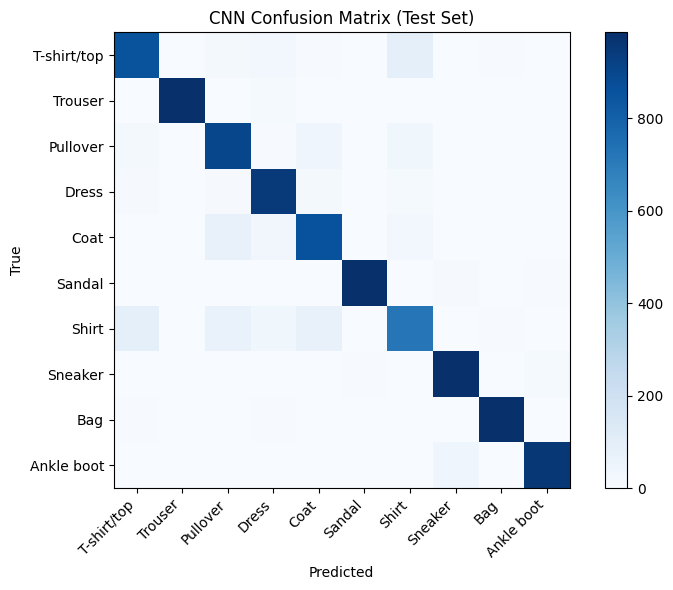

In [8]:
from sklearn.metrics import confusion_matrix
preds = np.argmax(model.predict(X_test), axis=1)

print(f"Test accuracy: {accuracy_score(y_test, preds):.4f}")
print(classification_report(y_test, preds, target_names=classes))

cm = confusion_matrix(y_test, preds)

plt.figure(figsize=(8, 6))
plt.imshow(cm, cmap='Blues')
plt.colorbar()
plt.xticks(range(10), classes, rotation=45, ha='right')
plt.yticks(range(10), classes)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('CNN Confusion Matrix (Test Set)')
plt.tight_layout()
plt.savefig('confusion_matrix_cnn.png', dpi=150)
plt.show()